# 03 — Hypothesis Testing

This notebook evaluates the Vanguard A/B test using completion rate, error rate, and session duration.

In [118]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)


## Load clean data

In [119]:

df = pd.read_csv("processed_data/clean_vanguard_data.csv")

df.head()


,client_id,visitor_id,visit_id,process_step,date_time,step_num,date,time,hour,weekday,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,variation,completed,session_duration_seconds,max_step
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,3,2017-04-17,15:27:07,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,test,False,645.0,3
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,2,2017-04-17,15:26:51,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,test,False,645.0,3
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,3,2017-04-17,15:19:22,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,test,False,645.0,3
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,2,2017-04-17,15:19:13,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,test,False,645.0,3
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,3,2017-04-17,15:18:04,15,Monday,5.0,64.0,79.0,U,2.0,189023.86,1.0,4.0,test,False,645.0,3


In [120]:

print("Dataset shape:", df.shape)
display(df["variation"].value_counts())


Dataset shape: (317235, 22)


variation
test       176699
control    140536
Name: count, dtype: int64

## Prepare data

In [121]:

df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

step_mapping = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["process_step"] = df["process_step"].str.lower().str.strip()
df["step_num"] = df["process_step"].map(step_mapping)


## Create session-level data

In [122]:

session_data = (
    df
    .groupby(["variation", "client_id", "visitor_id", "visit_id"], as_index=False)
    .agg(
        max_step=("step_num", "max"),
        first_timestamp=("date_time", "min"),
        last_timestamp=("date_time", "max"),
        number_of_steps=("process_step", "count")
    )
)

session_data["completed"] = session_data["max_step"] == 4

session_data["session_duration_seconds"] = (
    session_data["last_timestamp"] - session_data["first_timestamp"]
).dt.total_seconds()

session_data.head()


,variation,client_id,visitor_id,visit_id,max_step,first_timestamp,last_timestamp,number_of_steps,completed,session_duration_seconds
0,control,1028,42237450_62128060588,557292053_87239438319_391157,3,2017-04-08 18:51:28,2017-04-08 19:00:26,9,False,538.0
1,control,1104,194240915_18158000533,543158812_46395476577_767725,0,2017-06-12 07:49:18,2017-06-12 07:49:18,1,False,0.0
2,control,1104,194240915_18158000533,643221571_99977972121_69283,0,2017-06-20 22:31:33,2017-06-20 22:31:33,1,False,0.0
3,control,1186,446844663_31615102958,507052512_11309370126_442139,0,2017-04-08 15:59:16,2017-04-08 15:59:16,1,False,0.0
4,control,1186,446844663_31615102958,795373564_99931517312_810896,2,2017-04-08 18:05:02,2017-04-08 18:05:24,3,False,22.0



# Hypothesis Test 1 — Completion Rate

## Research Question

Did the new digital interface increase completion rate?

## Metric

Completion rate = completed sessions / total sessions

A session is completed when the user reaches the `confirm` step.

## Hypotheses

H₀: Completion rate is equal between control and test groups.

H₁: Completion rate is different between control and test groups.

Statistical test: two-proportion z-test.


In [123]:

completion_summary = (
    session_data
    .groupby("variation")
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

completion_summary["completion_rate"] = (
    completion_summary["completed_sessions"] /
    completion_summary["total_sessions"]
)

completion_summary["completion_rate_percent"] = (
    completion_summary["completion_rate"] * 100
)

completion_summary


,variation,total_sessions,completed_sessions,completion_rate,completion_rate_percent
0,control,32243,16088,0.498961,49.896101
1,test,37204,21791,0.585717,58.571659


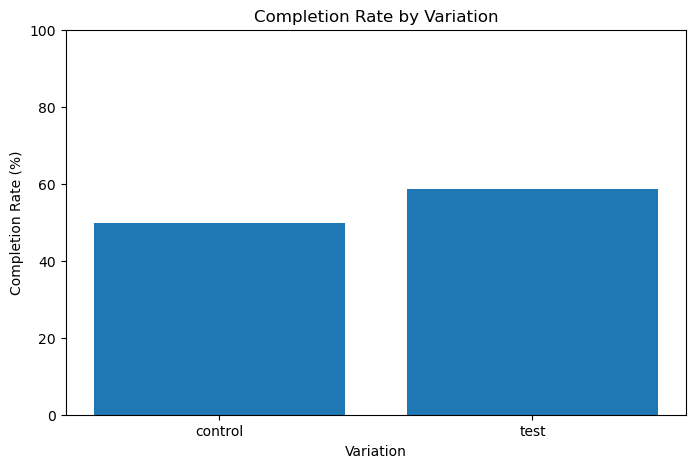

In [124]:

plt.figure(figsize=(8, 5))

plt.bar(
    completion_summary["variation"],
    completion_summary["completion_rate_percent"]
)

plt.title("Completion Rate by Variation")
plt.xlabel("Variation")
plt.ylabel("Completion Rate (%)")
plt.ylim(0, 100)

plt.show()


In [125]:

control = completion_summary[completion_summary["variation"] == "control"]
test = completion_summary[completion_summary["variation"] == "test"]

n_control = control["total_sessions"].values[0]
n_test = test["total_sessions"].values[0]

x_control = control["completed_sessions"].values[0]
x_test = test["completed_sessions"].values[0]

z_stat, p_value = proportions_ztest(
    [x_control, x_test],
    [n_control, n_test]
)

print("Control completed sessions:", x_control)
print("Control total sessions:", n_control)
print("Control completion rate:", round(x_control / n_control, 4))

print("Test completed sessions:", x_test)
print("Test total sessions:", n_test)
print("Test completion rate:", round(x_test / n_test, 4))

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))


Control completed sessions: 16088
Control total sessions: 32243
Control completion rate: 0.499
Test completed sessions: 21791
Test total sessions: 37204
Test completion rate: 0.5857
Z-statistic: -22.8989
P-value: 0.0


In [126]:

alpha = 0.05

if p_value < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in completion rates.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say completion rates are significantly different.")


Reject H0.
There is a statistically significant difference in completion rates.


In [127]:

control_rate = x_control / n_control
test_rate = x_test / n_test

absolute_lift = test_rate - control_rate
relative_lift = absolute_lift / control_rate

print("Control completion rate:", round(control_rate * 100, 2), "%")
print("Test completion rate:", round(test_rate * 100, 2), "%")
print("Absolute lift:", round(absolute_lift * 100, 2), "percentage points")
print("Relative lift:", round(relative_lift * 100, 2), "%")


Control completion rate: 49.9 %
Test completion rate: 58.57 %
Absolute lift: 8.68 percentage points
Relative lift: 17.39 %



## Completion Rate Conclusion

Use the p-value and lift above to decide whether the new interface created a meaningful improvement.

If p-value < 0.05, the difference is statistically significant.

If p-value >= 0.05, there is not enough statistical evidence to confirm a difference.


In [128]:
print("Control completion rate:", round(control_rate * 100, 2), "%")
print("Test completion rate:", round(test_rate * 100, 2), "%")
print("Absolute lift:", round(absolute_lift * 100, 2), "percentage points")
print("Relative lift:", round(relative_lift * 100, 2), "%")

Control completion rate: 49.9 %
Test completion rate: 58.57 %
Absolute lift: 8.68 percentage points
Relative lift: 17.39 %


# Completion Rate by Age Group

## Research Question

Did the new interface improve completion rates differently across age groups?

## Metric

Completion rate segmented by `age_group` and `variation`.

This helps identify whether certain age groups benefit more from the redesign.

In [129]:
completion_age = (
    session_data
    .merge(
        df[["client_id", "age_group"]].drop_duplicates(),
        on="client_id",
        how="left"
    )
    .groupby(["age_group", "variation"])
    .agg(
        total_sessions=("visit_id", "count"),
        completed_sessions=("completed", "sum")
    )
    .reset_index()
)

completion_age["completion_rate"] = (
    completion_age["completed_sessions"] / completion_age["total_sessions"]
)

completion_age["completion_rate_percent"] = completion_age["completion_rate"] * 100

completion_age

KeyError: "['age_group'] not in index"

In [ ]:
age_order = ["18-34", "35-44", "45-54", "55-64", "65+"]

completion_age["age_group"] = pd.Categorical(
    completion_age["age_group"],
    categories=age_order,
    ordered=True
)

pivot_table = completion_age.pivot(
    index="age_group",
    columns="variation",
    values="completion_rate_percent"
).reindex(age_order)

pivot_table.plot(kind="bar", figsize=(10, 6))

plt.title("Completion Rate by Age Group")
plt.ylabel("Completion Rate (%)")
plt.xlabel("Age Group")
plt.xticks(rotation=45)
plt.legend(title="Variation")
plt.show()

In [ ]:
completion_age_lift = completion_age.pivot(
    index="age_group",
    columns="variation",
    values="completion_rate"
).reindex(age_order)

completion_age_lift["lift"] = completion_age_lift["test"] - completion_age_lift["control"]
completion_age_lift["lift_percentage_points"] = completion_age_lift["lift"] * 100

completion_age_lift

NameError: name 'completion_age' is not defined


# Hypothesis Test 2 — Error Rate

## Research Question

Did the new interface reduce user errors?

## Metric

Error rate = backward movements / total actions

A backward movement happens when the user moves from a later step to an earlier step.

Examples:

- step_3 → step_2
- step_2 → step_1
- step_1 → start

Statistical test: two-proportion z-test.


In [ ]:

df_sorted = df.sort_values(
    by=["client_id", "visitor_id", "visit_id", "date_time"]
).copy()

df_sorted["previous_step_num"] = (
    df_sorted
    .groupby(["client_id", "visitor_id", "visit_id"])["step_num"]
    .shift(1)
)

# Calculate step difference
df_sorted["step_diff"] = df_sorted["step_num"] - df_sorted["previous_step_num"]

# Define errors:
# backward movement OR skipping forward more than 1 step
df_sorted["is_error"] = (
    (df_sorted["step_diff"] < 0) |   # backward
    (df_sorted["step_diff"] > 1)     # skip forward
)

df_sorted[
    ["client_id", "visit_id", "process_step", "step_num", "previous_step_num", "is_error"]
].head()


,client_id,visit_id,process_step,step_num,previous_step_num,is_error
70440,555,637149525_38041617439_716659,start,0,NaN,False
70439,555,637149525_38041617439_716659,step_1,1,0.0,False
70438,555,637149525_38041617439_716659,step_2,2,1.0,False
70437,555,637149525_38041617439_716659,step_3,3,2.0,False
70436,555,637149525_38041617439_716659,confirm,4,3.0,False


In [ ]:

error_summary = (
    df_sorted
    .groupby("variation")
    .agg(
        total_actions=("process_step", "count"),
        total_errors=("is_error", "sum")
    )
    .reset_index()

)

error_summary["error_rate"] = round(
    error_summary["total_errors"] /
    error_summary["total_actions"]
    ,4
)

error_summary["error_rate_percent"] = round(error_summary["error_rate"] * 100,2)

error_summary


,variation,total_actions,total_errors,error_rate,error_rate_percent
0,control,140536,9967,0.0709,7.09
1,test,176699,17061,0.0966,9.66


In [ ]:

control_error = error_summary[error_summary["variation"] == "control"]
test_error = error_summary[error_summary["variation"] == "test"]

n_control_error = control_error["total_actions"].values[0]
n_test_error = test_error["total_actions"].values[0]

x_control_error = control_error["total_errors"].values[0]
x_test_error = test_error["total_errors"].values[0]

z_stat_error, p_value_error = proportions_ztest(
    [x_control_error, x_test_error],
    [n_control_error, n_test_error]
)

print("Control error rate:", round(x_control_error / n_control_error * 100, 2), "%")
print("Test error rate:", round(x_test_error / n_test_error * 100, 2), "%")
print("Z-statistic:", round(z_stat_error, 4))
print("P-value:", round(p_value_error, 4))


Control error rate: 7.09 %
Test error rate: 9.66 %
Z-statistic: -25.6883
P-value: 0.0


In [ ]:

if p_value_error < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in error rates.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say error rates are significantly different.")


Reject H0.
There is a statistically significant difference in error rates.



# Hypothesis Test 3 — Session Duration

## Research Question

Did users in the test group complete sessions faster or slower?

## Metric

Session duration in seconds.

Statistical test: independent two-sample t-test.


In [ ]:

duration_data = session_data.copy()

duration_data = duration_data[
    duration_data["session_duration_seconds"].notna()
]

duration_data = duration_data[
    duration_data["session_duration_seconds"] >= 0
]

q1 = duration_data["session_duration_seconds"].quantile(0.25)
q3 = duration_data["session_duration_seconds"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

duration_no_outliers = duration_data[
    (duration_data["session_duration_seconds"] >= lower_bound) &
    (duration_data["session_duration_seconds"] <= upper_bound)
]

print("Original duration rows:", len(duration_data))
print("Rows after outlier removal:", len(duration_no_outliers))


Original duration rows: 69447
Rows after outlier removal: 64135


In [ ]:

duration_summary = (
    duration_no_outliers
    .groupby("variation")
    .agg(
        average_duration=("session_duration_seconds", "mean"),
        median_duration=("session_duration_seconds", "median"),
        session_count=("session_duration_seconds", "count")
    )
    .reset_index()
)

duration_summary


,variation,average_duration,median_duration,session_count
0,control,187.814586,141.0,29987
1,test,195.994729,149.0,34148


In [ ]:

control_duration = duration_no_outliers[
    duration_no_outliers["variation"] == "control"
]["session_duration_seconds"]

test_duration = duration_no_outliers[
    duration_no_outliers["variation"] == "test"
]["session_duration_seconds"]

t_stat, p_value_duration = ttest_ind(
    control_duration,
    test_duration,
    equal_var=False
)

print("Control average duration:", round(control_duration.mean(), 2))
print("Test average duration:", round(test_duration.mean(), 2))
print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value_duration, 4))


Control average duration: 187.81
Test average duration: 195.99
T-statistic: -5.4364
P-value: 0.0


In [ ]:

if p_value_duration < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in average session duration.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say average session duration is significantly different.")


Reject H0.
There is a statistically significant difference in average session duration.



# Hypothesis Test 4 — Digital Engagement

## Research Question

Did the redesigned digital experience increase customer engagement with Vanguard’s digital platform?

## Metric

Digital engagement is measured using client contact/activity over the last 6 months.

For this analysis, the main variable is:

`calls_6_mnth`

This represents the number of calls/interactions recorded for a client in the last 6 months.

## Hypotheses

H₀: The average digital engagement is equal between the control and test groups.

H₁: The average digital engagement is different between the control and test groups.

Statistical test: independent two-sample t-test.


In [ ]:

engagement_data = df.copy()

engagement_data = engagement_data[
    engagement_data["calls_6_mnth"].notna()
]

engagement_data = engagement_data[
    engagement_data["variation"].isin(["control", "test"])
]

engagement_summary = (
    engagement_data
    .groupby("variation")
    .agg(
        average_calls_6_months=("calls_6_mnth", "mean"),
        median_calls_6_months=("calls_6_mnth", "median"),
        total_clients=("client_id", "nunique")
    )
    .reset_index()
)

engagement_summary


,variation,average_calls_6_months,median_calls_6_months,total_clients
0,control,3.267755,3.0,23527
1,test,3.201986,3.0,26961


In [ ]:

control_engagement = engagement_data[
    engagement_data["variation"] == "control"
]["calls_6_mnth"]

test_engagement = engagement_data[
    engagement_data["variation"] == "test"
]["calls_6_mnth"]

t_stat_engagement, p_value_engagement = ttest_ind(
    control_engagement,
    test_engagement,
    equal_var=False
)

print("Control average calls in last 6 months:", round(control_engagement.mean(), 2))
print("Test average calls in last 6 months:", round(test_engagement.mean(), 2))
print("T-statistic:", round(t_stat_engagement, 4))
print("P-value:", round(p_value_engagement, 4))


Control average calls in last 6 months: 3.27
Test average calls in last 6 months: 3.2
T-statistic: 8.3939
P-value: 0.0


In [ ]:

alpha = 0.05

if p_value_engagement < alpha:
    print("Reject H0.")
    print("There is a statistically significant difference in digital engagement between groups.")
else:
    print("Fail to reject H0.")
    print("There is not enough evidence to say digital engagement is significantly different between groups.")


Reject H0.
There is a statistically significant difference in digital engagement between groups.


In [ ]:

alpha = 0.05

print("========== FINAL RESULTS ==========")

print("\nCOMPLETION RATE")
control_rate = x_control / n_control
test_rate = x_test / n_test
absolute_lift = test_rate - control_rate

print(f"Control: {round(control_rate*100,2)}%")
print(f"Test: {round(test_rate*100,2)}%")
print(f"Lift: {round(absolute_lift*100,2)} percentage points")
print(f"P-value: {round(p_value,4)}")

if p_value < alpha:
    print("Result: Statistically significant")
else:
    print("Result: NOT statistically significant")

print("\nERROR RATE")
control_err_rate = x_control_error / n_control_error
test_err_rate = x_test_error / n_test_error

print(f"Control: {round(control_err_rate*100,2)}%")
print(f"Test: {round(test_err_rate*100,2)}%")
print(f"P-value: {round(p_value_error,4)}")

if p_value_error < alpha:
    print("Result: Statistically significant")
else:
    print("Result: NOT statistically significant")

print("\nSESSION DURATION")
print(f"Control avg: {round(control_duration.mean(),2)} sec")
print(f"Test avg: {round(test_duration.mean(),2)} sec")
print(f"P-value: {round(p_value_duration,4)}")

if p_value_duration < alpha:
    print("Result: Statistically significant")
else:
    print("Result: NOT statistically significant")

print("\nDIGITAL ENGAGEMENT")
print(f"Control avg calls: {round(control_engagement.mean(),2)}")
print(f"Test avg calls: {round(test_engagement.mean(),2)}")
print(f"P-value: {round(p_value_engagement,4)}")

if p_value_engagement < alpha:
    print("Result: Statistically significant")
else:
    print("Result: NOT statistically significant")


========== FINAL RESULTS ==========

COMPLETION RATE
Control: 49.9%
Test: 58.57%
Lift: 8.68 percentage points
P-value: 0.0
Result: Statistically significant

ERROR RATE
Control: 7.09%
Test: 9.66%
P-value: 0.0
Result: Statistically significant

SESSION DURATION
Control avg: 187.81 sec
Test avg: 195.99 sec
P-value: 0.0
Result: Statistically significant

DIGITAL ENGAGEMENT
Control avg calls: 3.27
Test avg calls: 3.2
P-value: 0.0
Result: Statistically significant



# Final Conclusion

## Completion Rate

The completion rate test compares whether users in the test group reached the confirmation step more often than users in the control group.

If the test group has a higher completion rate and the p-value is below 0.05, then the redesign can be considered statistically valid for improving completion.

## Error Rate

The error rate test evaluates whether the new interface reduced backward movements in the process.

If the test group has a lower error rate and the p-value is below 0.05, then the redesign likely improved navigation.

## Session Duration

The session duration test evaluates whether users spent significantly different amounts of time in the process.

A lower or reasonable session duration can support the conclusion that the process became smoother.

## Digital Engagement

The digital engagement test evaluates whether the redesign increased customer activity on Vanguard’s digital platform.

This was measured using `calls_6_mnth`, which captures customer activity over the last 6 months.

If the test group has a higher average number of calls and the p-value is below 0.05, then the redesign may be considered to have significantly increased digital engagement.

## Final Decision

The redesign is considered a **valid improvement** only if the numerical results show:

- Higher completion rate
- Statistically significant completion result
- No significant worsening in error rate
- Reasonable session duration
- Positive or statistically significant digital engagement

If these conditions are not met, the redesign should be considered **not fully validated** or **inconclusive**.
